# Quantum Harmonic Oscillator on a Grid

This notebook discretizes the dimensionless harmonic oscillator

$$H=-\frac{1}{2}\frac{d^2}{dx^2}+\frac{1}{2}x^2.$$

The exact energies are `n + 1/2`. We compare the finite-difference spectrum with this analytic result and use a low-energy polynomial filter to isolate the ground state.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.pde import dirichlet_laplacian_1d
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian
from qsvt.templates import exponential_approximation_polynomial

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_points = 80
xmax = 7.0
length = 2.0 * xmax
dx = length / (n_points + 1)
x = np.linspace(-xmax + dx, xmax - dx, n_points)

_, negative_laplacian = dirichlet_laplacian_1d(n_points, length=length)
H = 0.5 * negative_laplacian + np.diag(0.5 * x**2)

eigenvalues, eigenvectors = eigh_hermitian(H)
analytic = np.arange(6) + 0.5
spectrum_error = np.max(np.abs(eigenvalues[:4] - analytic[:4]))

eigenvalues[:6], spectrum_error

(array([0.4991, 1.4953, 2.4878, 3.4765, 4.4614, 5.4424]),
 np.float64(0.02350013331927281))

In [3]:
center = 0.5 * (eigenvalues[0] + eigenvalues[-1])
half_width = 0.5 * (eigenvalues[-1] - eigenvalues[0])
A = (center * np.eye(n_points) - H) / half_width

coeffs = exponential_approximation_polynomial(degree=18, beta=8.0)
trial = np.exp(-(x**2) / 2.5)
trial = trial / np.linalg.norm(trial)
filtered = apply_polynomial_to_hermitian(A, coeffs) @ trial
filtered = filtered / np.linalg.norm(filtered)

ground = eigenvectors[:, 0]
ground_overlap = np.abs(np.vdot(ground, filtered)) ** 2

ground_overlap

np.float64(0.9969945579767748)

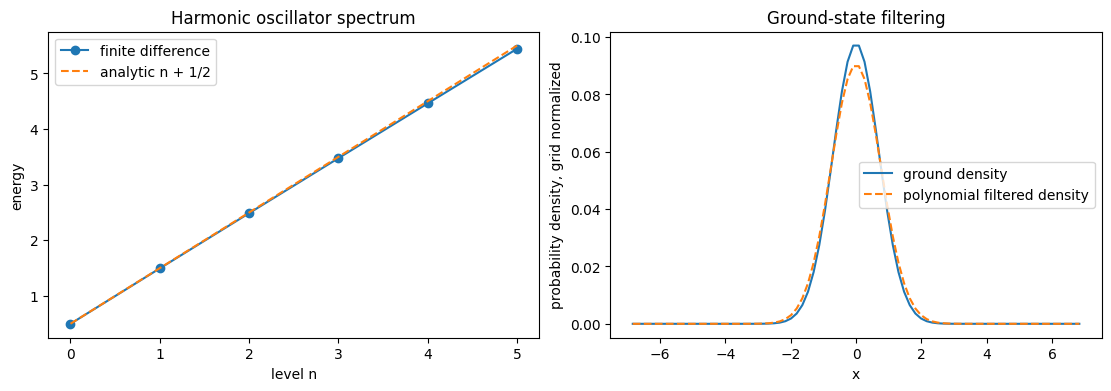

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

indices = np.arange(6)
axes[0].plot(indices, eigenvalues[:6], "o-", label="finite difference")
axes[0].plot(indices, analytic, "--", label="analytic n + 1/2")
axes[0].set_xlabel("level n")
axes[0].set_ylabel("energy")
axes[0].set_title("Harmonic oscillator spectrum")
axes[0].legend()

axes[1].plot(x, ground**2, label="ground density")
axes[1].plot(x, filtered**2, "--", label="polynomial filtered density")
axes[1].set_xlabel("x")
axes[1].set_ylabel("probability density, grid normalized")
axes[1].set_title("Ground-state filtering")
axes[1].legend()

plt.show()

## Validation

Compact checks against the analytic oscillator spectrum and filtered ground state.


In [5]:
assert spectrum_error < 0.04
assert ground_overlap > 0.95
assert np.all(np.diff(eigenvalues[:6]) > 0.8)

print("finite_difference_energies:", np.array2string(eigenvalues[:6], precision=4))
print("analytic_energies:", np.array2string(analytic, precision=4))
print(f"spectrum_error_first_four: {spectrum_error:.4e}")
print(f"ground_overlap: {ground_overlap:.4f}")
print("validation: passed")

finite_difference_energies: [0.4991 1.4953 2.4878 3.4765 4.4614 5.4424]
analytic_energies: [0.5 1.5 2.5 3.5 4.5 5.5]
spectrum_error_first_four: 2.3500e-02
ground_overlap: 0.9970
validation: passed
